## Notebook 09 - Team-level multivariate analysis: predicting league points
Núria Pascual Salas

**Content:** Performs a multivariate analysis to test which network metrics are related to team performance (total league points) in LaLiga 2023-24. It compares three methods: pairwise Pearson correlations, Lasso regression for feature selection, and Random Forest for non-linear feature importance. Since individual metrics show weak relationships with points, the analysis tests whether combinations of metrics provide useful information and whether the relationships are linear or more complex.

**Inputs:**
- multimetric_profile.csv (from notebook 08)

**Outputs:**
- outputs/csv/multivariate_results.csv (coefficients and feature importances)
- outputs/figures/pairwise_correlations_with_points.png
- outputs/figures/lasso_coefficients_path.png
- outputs/figures/random_forest_feature_importance.png
- outputs/figures/model_comparison.png

**Used in:** Chapter 5 (team-level prediction) and Appendix C.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr
from sklearn.linear_model import LinearRegression, Lasso, LassoCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import LeaveOneOut, cross_val_score
from sklearn.metrics import r2_score, mean_squared_error
import warnings
warnings.filterwarnings('ignore')
import os

FIGURES_DIR = 'outputs/figures'
CSV_DIR     = 'outputs/csv'
os.makedirs(FIGURES_DIR, exist_ok=True)
os.makedirs(CSV_DIR, exist_ok=True)

### 1. Load the multimetric profile

In [3]:
df = pd.read_csv(f'{CSV_DIR}/multimetric_profile.csv')
print(f"Number of teams: {len(df)}")
print(f"\nColumns available: {list(df.columns)}")
print()
print(df.head().to_string(index=False))

Number of teams: 20

Columns available: ['team', 'r_sf_points', 'total_points', 'n_nodes', 'n_edges', 'density', 'efficiency', 'clustering', 'avg_path_length', 'reciprocity', 'fragility_pagerank', 'fragility_betweenness']

           team  r_sf_points  total_points  n_nodes  n_edges  density  efficiency  clustering  avg_path_length  reciprocity  fragility_pagerank  fragility_betweenness
      Barcelona    -0.203419            82       29      591   0.7278      0.8867      0.0806           1.2722       0.9374              0.2502                 0.2831
     Celta Vigo    -0.158229            42       31      672   0.7226      0.8935      0.0501           1.2785       0.9107              0.1865                 0.2221
     Real Betis    -0.148056            60       35      824   0.6924      0.8773      0.0618           1.3084       0.9102              0.3295                 0.3491
Atlético Madrid    -0.042618            74       27      502   0.7151      0.8775      0.0712           1.245

### 2. Define features and target

In [4]:
target_col = 'total_points'

exclude_cols = ['team', 'team_id', target_col]
feature_cols = [c for c in df.columns if c not in exclude_cols]

X = df[feature_cols].values
y = df[target_col].values

print(f"Features ({len(feature_cols)}):")
for i, f in enumerate(feature_cols, 1):
    print(f"  {i:2d}. {f}")
print(f"\nTarget: {target_col}")
print(f"X shape: {X.shape}")
print(f"y range: {y.min()} to {y.max()}")

Features (10):
   1. r_sf_points
   2. n_nodes
   3. n_edges
   4. density
   5. efficiency
   6. clustering
   7. avg_path_length
   8. reciprocity
   9. fragility_pagerank
  10. fragility_betweenness

Target: total_points
X shape: (20, 10)
y range: 19 to 97


### 3. Pairwise correlations with points

In [5]:
pairwise_results = []

for feature in feature_cols:
    r, p = pearsonr(df[feature], df[target_col])
    pairwise_results.append({
        'feature': feature,
        'r':       round(r, 3),
        'p_value': round(p, 4),
        'abs_r':   abs(r),
    })

df_pairwise = pd.DataFrame(pairwise_results).sort_values('abs_r', ascending=False).reset_index(drop=True)
print("Bivariate correlations with total_points (sorted by |r|):")
print(df_pairwise[['feature', 'r', 'p_value']].to_string(index=False))

Bivariate correlations with total_points (sorted by |r|):
              feature      r  p_value
              n_nodes -0.590   0.0062
      avg_path_length -0.497   0.0258
          reciprocity  0.471   0.0359
              n_edges -0.469   0.0369
              density  0.444   0.0496
           efficiency  0.428   0.0599
   fragility_pagerank -0.396   0.0835
          r_sf_points -0.274   0.2421
           clustering  0.259   0.2706
fragility_betweenness -0.252   0.2834


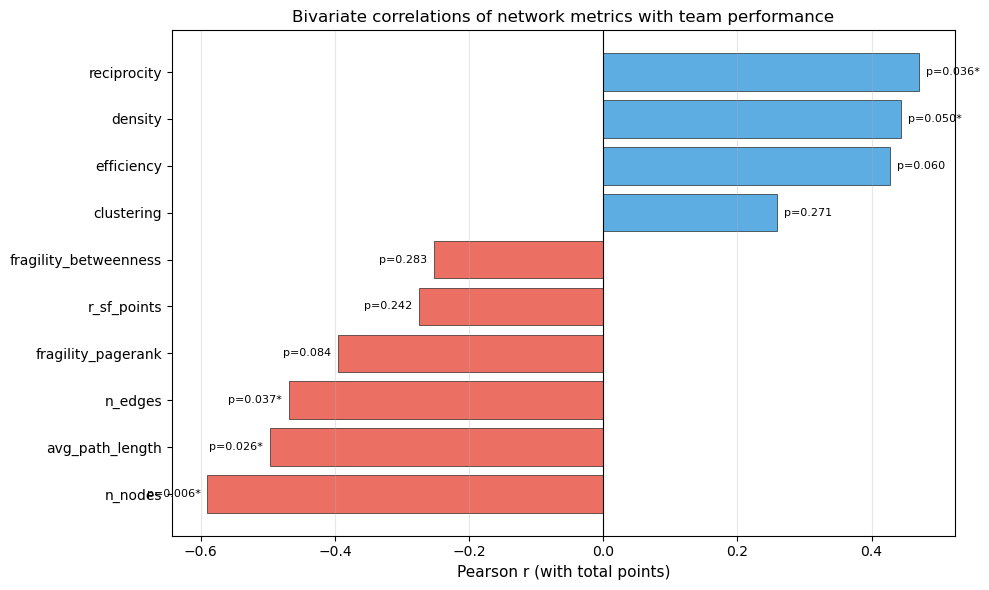

In [6]:
# Bar plot of correlations
fig, ax = plt.subplots(figsize=(10, 6))

df_plot = df_pairwise.sort_values('r')
colors = ['#e74c3c' if r < 0 else '#3498db' for r in df_plot['r']]

ax.barh(df_plot['feature'], df_plot['r'], color=colors, alpha=0.8,
        edgecolor='black', linewidth=0.5)
ax.axvline(x=0, color='black', linewidth=0.8)
ax.set_xlabel('Pearson r (with total points)', fontsize=11)
ax.set_title('Bivariate correlations of network metrics with team performance',
             fontsize=12)
ax.grid(axis='x', alpha=0.3)

# We add the p-values
for i, (_, row) in enumerate(df_plot.iterrows()):
    offset = 0.01 if row['r'] >= 0 else -0.01
    ha = 'left' if row['r'] >= 0 else 'right'
    sig = '*' if row['p_value'] < 0.05 else ''
    ax.text(row['r'] + offset, i, f"p={row['p_value']:.3f}{sig}",
            va='center', ha=ha, fontsize=8)

plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/pairwise_correlations_with_points.png',
            dpi=130, bbox_inches='tight')
plt.show()

### 4. Linear regression: full model with all features

In [7]:
# Standardize features (mean=0, std=1) so coefficients are comparable
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Full linear regression
lr_full = LinearRegression()
lr_full.fit(X_scaled, y)
y_pred_full = lr_full.predict(X_scaled)

r2_full = r2_score(y, y_pred_full)
rmse_full = np.sqrt(mean_squared_error(y, y_pred_full))

print(f"Full linear regression (in-sample fit):")
print(f"  R² = {r2_full:.3f}")
print(f"  RMSE = {rmse_full:.2f}")
print()

df_coef_full = pd.DataFrame({
    'feature':     feature_cols,
    'coefficient': lr_full.coef_,
    'abs_coef':    np.abs(lr_full.coef_),
}).sort_values('abs_coef', ascending=False).reset_index(drop=True)

print("Coefficients sorted by magnitude:")
print(df_coef_full[['feature', 'coefficient']].to_string(index=False))

Full linear regression (in-sample fit):
  R² = 0.670
  RMSE = 11.44

Coefficients sorted by magnitude:
              feature  coefficient
              density  -231.351410
           efficiency   185.629962
          reciprocity    46.888370
              n_nodes   -43.329345
              n_edges    29.507722
fragility_betweenness    25.796664
   fragility_pagerank   -24.943623
      avg_path_length     1.661879
          r_sf_points    -1.047821
           clustering     0.354136


### 5. Leave-One-Out cross-validation: linear model

In [19]:
loo = LeaveOneOut()

# LOO-CV for full linear regression
predictions_loo = []
y_test_loo     = []

for train_idx, test_idx in loo.split(X_scaled):
    X_train, X_test = X_scaled[train_idx], X_scaled[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]
    
    lr = LinearRegression()
    lr.fit(X_train, y_train)
    predictions_loo.append(lr.predict(X_test)[0])
    y_test_loo.append(y_test[0])

predictions_loo = np.array(predictions_loo)
y_test_loo     = np.array(y_test_loo)

r2_loo   = r2_score(y_test_loo, predictions_loo)
rmse_loo = np.sqrt(mean_squared_error(y_test_loo, predictions_loo))

print(f"Leave-One-Out cross-validation (full linear model):")
print(f"  R² = {r2_loo:.3f}")
print(f"  RMSE = {rmse_loo:.2f}")
print()
print(f"For comparison: in-sample R² was {r2_full:.3f}")

Leave-One-Out cross-validation (full linear model):
  R² = -2.470
  RMSE = 37.10

For comparison: in-sample R² was 0.670


### 6. Lasso regularization: variable selection

In [9]:
# LassoCV finds the optimal alpha by cross-validation
lasso_cv = LassoCV(cv=5, random_state=42, max_iter=10000, alphas=np.logspace(-3, 2, 50))
lasso_cv.fit(X_scaled, y)

print(f"Optimal alpha (Lasso CV): {lasso_cv.alpha_:.4f}")
print()

df_lasso = pd.DataFrame({
    'feature':     feature_cols,
    'coefficient': lasso_cv.coef_,
    'abs_coef':    np.abs(lasso_cv.coef_),
}).sort_values('abs_coef', ascending=False).reset_index(drop=True)

selected_features = df_lasso[df_lasso['coefficient'] != 0]['feature'].tolist()

print("Lasso coefficients (sorted by magnitude):")
print(df_lasso[['feature', 'coefficient']].to_string(index=False))
print()
print(f"Features selected by Lasso (non-zero coefficients): {len(selected_features)}")
for f in selected_features:
    print(f"  - {f}")

Optimal alpha (Lasso CV): 3.7276

Lasso coefficients (sorted by magnitude):
              feature  coefficient
              n_nodes    -8.227922
          r_sf_points    -2.451752
              n_edges    -0.000000
              density     0.000000
           efficiency     0.000000
           clustering     0.000000
      avg_path_length    -0.000000
          reciprocity     0.000000
   fragility_pagerank    -0.000000
fragility_betweenness    -0.000000

Features selected by Lasso (non-zero coefficients): 2
  - n_nodes
  - r_sf_points


### 7. Lasso coefficient path

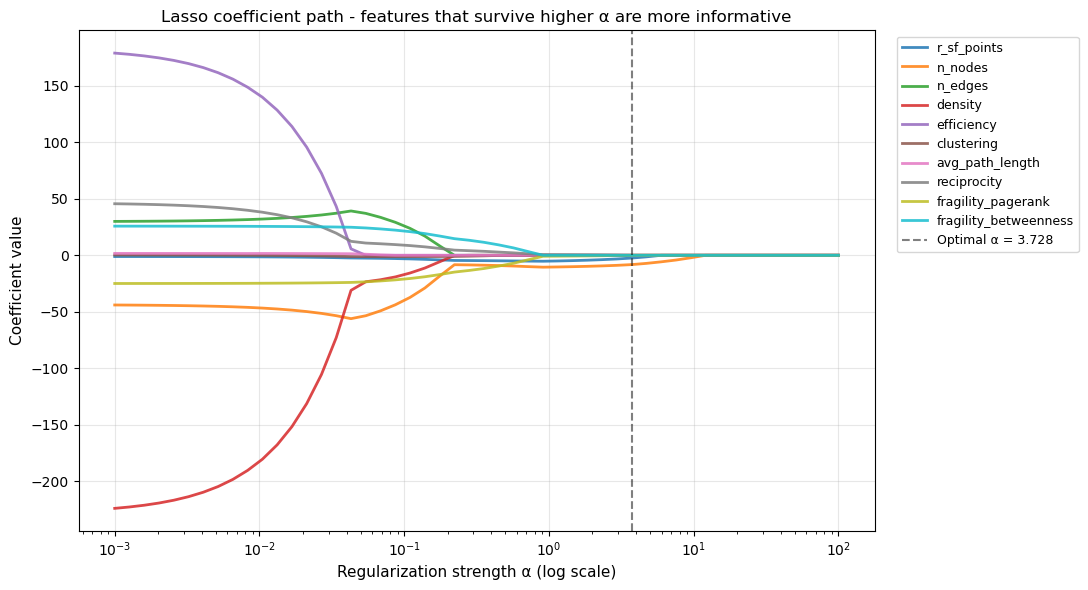

In [10]:
alphas = np.logspace(-3, 2, 50)
coefs_path = []

for alpha in alphas:
    lasso = Lasso(alpha=alpha, max_iter=10000)
    lasso.fit(X_scaled, y)
    coefs_path.append(lasso.coef_)

coefs_path = np.array(coefs_path)

fig, ax = plt.subplots(figsize=(11, 6))
for i, feature in enumerate(feature_cols):
    ax.plot(alphas, coefs_path[:, i], label=feature, linewidth=2, alpha=0.85)

ax.axvline(x=lasso_cv.alpha_, color='black', linestyle='--', alpha=0.5,
           label=f'Optimal α = {lasso_cv.alpha_:.3f}')
ax.set_xscale('log')
ax.set_xlabel('Regularization strength α (log scale)', fontsize=11)
ax.set_ylabel('Coefficient value', fontsize=11)
ax.set_title('Lasso coefficient path - features that survive higher α are more informative',
             fontsize=12)
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/lasso_coefficients_path.png',
            dpi=130, bbox_inches='tight')
plt.show()

### 8. Lasso performance (LOO cross-validation)

In [11]:
predictions_lasso = []
y_test_lasso     = []

for train_idx, test_idx in loo.split(X_scaled):
    X_train, X_test = X_scaled[train_idx], X_scaled[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]
    
    lasso = Lasso(alpha=lasso_cv.alpha_, max_iter=10000)
    lasso.fit(X_train, y_train)
    predictions_lasso.append(lasso.predict(X_test)[0])
    y_test_lasso.append(y_test[0])

predictions_lasso = np.array(predictions_lasso)
y_test_lasso     = np.array(y_test_lasso)

r2_lasso   = r2_score(y_test_lasso, predictions_lasso)
rmse_lasso = np.sqrt(mean_squared_error(y_test_lasso, predictions_lasso))

print(f"Lasso (Leave-One-Out CV):")
print(f"  R² = {r2_lasso:.3f}")
print(f"  RMSE = {rmse_lasso:.2f}")

Lasso (Leave-One-Out CV):
  R² = 0.002
  RMSE = 19.89


### 9. Random Forest: non-linear model

In [12]:
rf = RandomForestRegressor(n_estimators=300, max_depth=5, random_state=42)
rf.fit(X, y)   # Random Forest doesn't require standardization

df_rf = pd.DataFrame({
    'feature':    feature_cols,
    'importance': rf.feature_importances_,
}).sort_values('importance', ascending=False).reset_index(drop=True)

print("Random Forest feature importance:")
print(df_rf.to_string(index=False))

Random Forest feature importance:
              feature  importance
          reciprocity    0.223487
          r_sf_points    0.203319
              n_nodes    0.131363
              n_edges    0.094820
   fragility_pagerank    0.074166
           clustering    0.072072
              density    0.064794
           efficiency    0.052840
      avg_path_length    0.043671
fragility_betweenness    0.039467


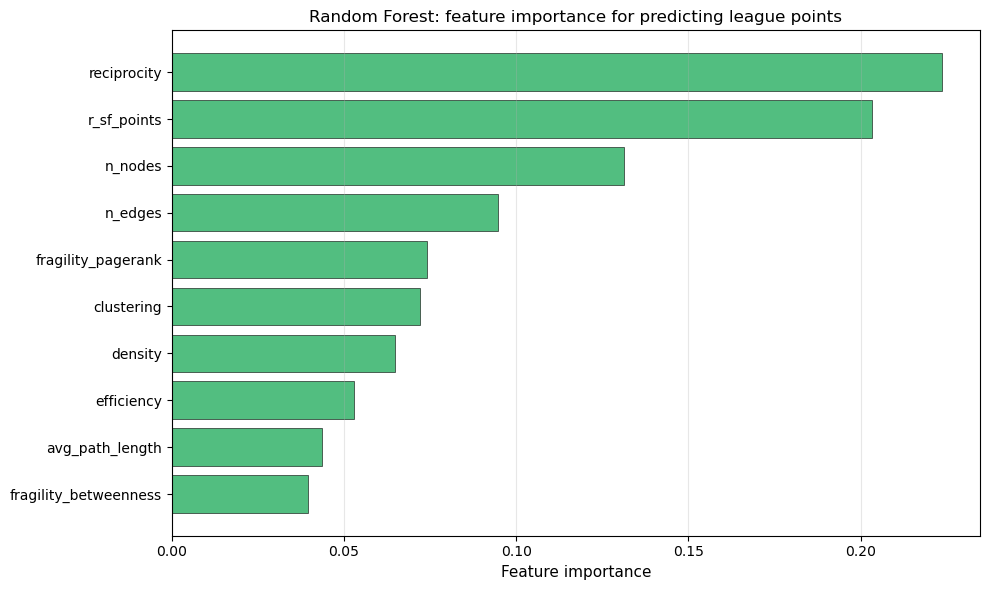

In [13]:
# Feature importance bar plot
fig, ax = plt.subplots(figsize=(10, 6))
df_rf_sorted = df_rf.sort_values('importance')
ax.barh(df_rf_sorted['feature'], df_rf_sorted['importance'],
        color='#27ae60', alpha=0.8, edgecolor='black', linewidth=0.5)
ax.set_xlabel('Feature importance', fontsize=11)
ax.set_title('Random Forest: feature importance for predicting league points',
             fontsize=12)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/random_forest_feature_importance.png',
            dpi=130, bbox_inches='tight')
plt.show()

In [14]:
# Random Forest LOO-CV
predictions_rf = []
y_test_rf     = []

for train_idx, test_idx in loo.split(X):
    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]
    
    rf_loo = RandomForestRegressor(n_estimators=300, max_depth=5, random_state=42)
    rf_loo.fit(X_train, y_train)
    predictions_rf.append(rf_loo.predict(X_test)[0])
    y_test_rf.append(y_test[0])

predictions_rf = np.array(predictions_rf)
y_test_rf     = np.array(y_test_rf)

r2_rf   = r2_score(y_test_rf, predictions_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test_rf, predictions_rf))

print(f"Random Forest (Leave-One-Out CV):")
print(f"  R² = {r2_rf:.3f}")
print(f"  RMSE = {rmse_rf:.2f}")

Random Forest (Leave-One-Out CV):
  R² = -0.059
  RMSE = 20.49


### 10. Model comparison


In [15]:
df_comparison = pd.DataFrame([
    {'model': 'Linear (full)',  'R²_in_sample': r2_full,  'R²_LOO': r2_loo,   'RMSE_LOO': rmse_loo},
    {'model': 'Lasso',          'R²_in_sample': np.nan,   'R²_LOO': r2_lasso, 'RMSE_LOO': rmse_lasso},
    {'model': 'Random Forest',  'R²_in_sample': np.nan,   'R²_LOO': r2_rf,    'RMSE_LOO': rmse_rf},
])
print(df_comparison.to_string(index=False))

        model  R²_in_sample    R²_LOO  RMSE_LOO
Linear (full)      0.669925 -2.469979 37.098372
        Lasso           NaN  0.002361 19.891982
Random Forest           NaN -0.058910 20.493722


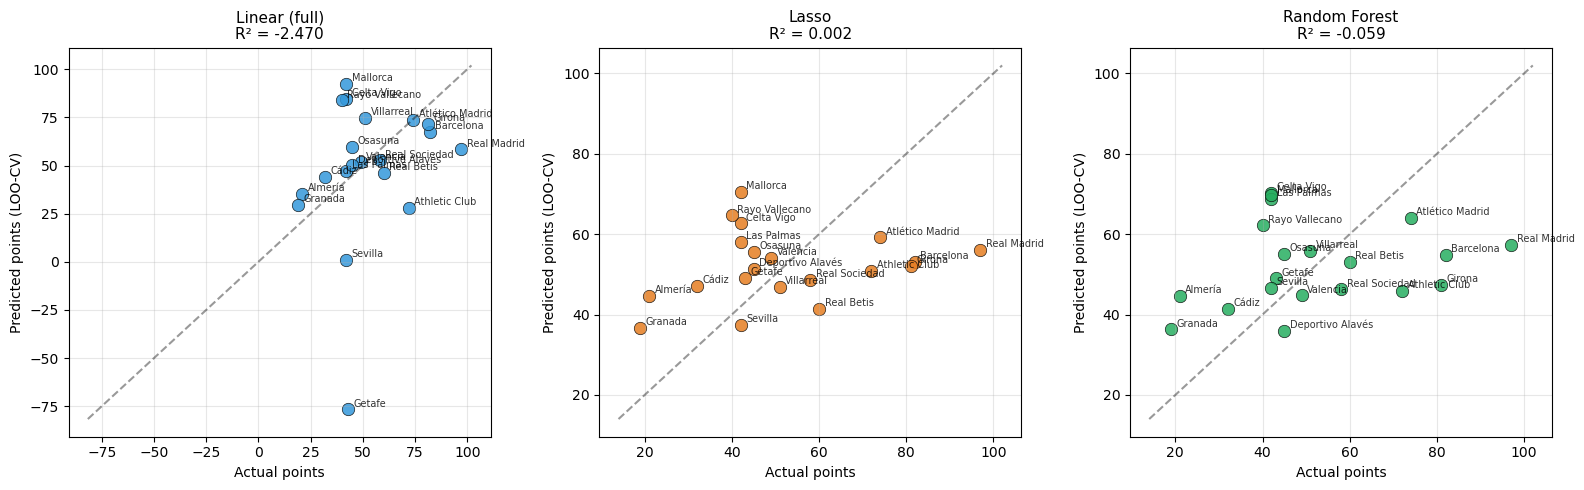

In [16]:
# Predicted vs actual
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

models_preds = [
    ('Linear (full)', y_test_loo,   predictions_loo,   '#3498db'),
    ('Lasso',         y_test_lasso, predictions_lasso, '#e67e22'),
    ('Random Forest', y_test_rf,    predictions_rf,    '#27ae60'),
]

for ax, (name, y_t, y_p, color) in zip(axes, models_preds):
    r2 = r2_score(y_t, y_p)
    ax.scatter(y_t, y_p, color=color, s=80, alpha=0.85,
               edgecolors='black', linewidths=0.5)
    
    # Diagonal y=x
    lims = [min(y_t.min(), y_p.min()) - 5, max(y_t.max(), y_p.max()) + 5]
    ax.plot(lims, lims, 'k--', alpha=0.4, label='Perfect prediction')
    
    # Team labels
    for team_name, yt, yp in zip(df['team'], y_t, y_p):
        ax.annotate(team_name, (yt, yp), fontsize=7,
                    textcoords='offset points', xytext=(4, 2), alpha=0.8)
    
    ax.set_xlabel('Actual points', fontsize=10)
    ax.set_ylabel('Predicted points (LOO-CV)', fontsize=10)
    ax.set_title(f'{name}\nR² = {r2:.3f}', fontsize=11)
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/model_comparison.png',
            dpi=130, bbox_inches='tight')
plt.show()

### 11. Save the multivariate results

In [17]:
df_results = pd.DataFrame({
    'feature':           feature_cols,
    'pearson_r':         [df_pairwise[df_pairwise['feature']==f]['r'].values[0] for f in feature_cols],
    'pearson_p':         [df_pairwise[df_pairwise['feature']==f]['p_value'].values[0] for f in feature_cols],
    'linear_coef':       lr_full.coef_,
    'lasso_coef':        lasso_cv.coef_,
    'rf_importance':     rf.feature_importances_,
}).round(4)

df_results.to_csv(f'{CSV_DIR}/multivariate_results.csv', index=False)
print(df_results.to_string(index=False))

              feature  pearson_r  pearson_p  linear_coef  lasso_coef  rf_importance
          r_sf_points     -0.274     0.2421      -1.0478     -2.4518         0.2033
              n_nodes     -0.590     0.0062     -43.3293     -8.2279         0.1314
              n_edges     -0.469     0.0369      29.5077     -0.0000         0.0948
              density      0.444     0.0496    -231.3514      0.0000         0.0648
           efficiency      0.428     0.0599     185.6300      0.0000         0.0528
           clustering      0.259     0.2706       0.3541      0.0000         0.0721
      avg_path_length     -0.497     0.0258       1.6619     -0.0000         0.0437
          reciprocity      0.471     0.0359      46.8884      0.0000         0.2235
   fragility_pagerank     -0.396     0.0835     -24.9436     -0.0000         0.0742
fragility_betweenness     -0.252     0.2834      25.7967     -0.0000         0.0395


### Summary

In [18]:
print("=" * 70)
print("SUMMARY - Multivariate prediction of LaLiga 2023-24 points")
print("=" * 70)
print()
print(f"Sample size: n = {len(df)} teams")
print(f"Features:    {len(feature_cols)}")
print()
print("--- Bivariate (top 3 strongest correlations) ---")
for _, row in df_pairwise.head(3).iterrows():
    sig = '*' if row['p_value'] < 0.05 else ''
    print(f"  {row['feature']:25s} r = {row['r']:+.3f}  p = {row['p_value']:.4f} {sig}")
print()
print("--- Lasso (selected features) ---")
if len(selected_features) == 0:
    print("  No features selected - all coefficients shrunk to zero.")
    print("  Interpretation: no metric (alone or in combination) has")
    print("  sufficient signal beyond noise.")
else:
    for f in selected_features:
        coef = df_lasso[df_lasso['feature']==f]['coefficient'].values[0]
        print(f"  {f:25s} coef = {coef:+.3f}")
print()
print("--- Random Forest (top 3 by importance) ---")
for _, row in df_rf.head(3).iterrows():
    print(f"  {row['feature']:25s} importance = {row['importance']:.3f}")
print()
print("--- Model performance (LOO cross-validation) ---")
print(f"  Linear (full):  R² = {r2_loo:+.3f}")
print(f"  Lasso:          R² = {r2_lasso:+.3f}")
print(f"  Random Forest:  R² = {r2_rf:+.3f}")
print()

SUMMARY - Multivariate prediction of LaLiga 2023-24 points

Sample size: n = 20 teams
Features:    10

--- Bivariate (top 3 strongest correlations) ---
  n_nodes                   r = -0.590  p = 0.0062 *
  avg_path_length           r = -0.497  p = 0.0258 *
  reciprocity               r = +0.471  p = 0.0359 *

--- Lasso (selected features) ---
  n_nodes                   coef = -8.228
  r_sf_points               coef = -2.452

--- Random Forest (top 3 by importance) ---
  reciprocity               importance = 0.223
  r_sf_points               importance = 0.203
  n_nodes                   importance = 0.131

--- Model performance (LOO cross-validation) ---
  Linear (full):  R² = -2.470
  Lasso:          R² = +0.002
  Random Forest:  R² = -0.059

